# 2D Ising 模拟结果总结（L=6）

本节对 Metropolis 与 Wolff 两种更新算法的模拟结果进行对比，绘制：

- 每自旋能量 $E/N$
- 每自旋绝对磁化 $|M|/N$
- 每自旋比热 $C_v/N$
- 每自旋磁化率 $\chi/N$

并参考二维 Ising 理论临界温度

$$
T_c = \frac{2}{\ln(1+\sqrt{2})} \approx 2.269
$$

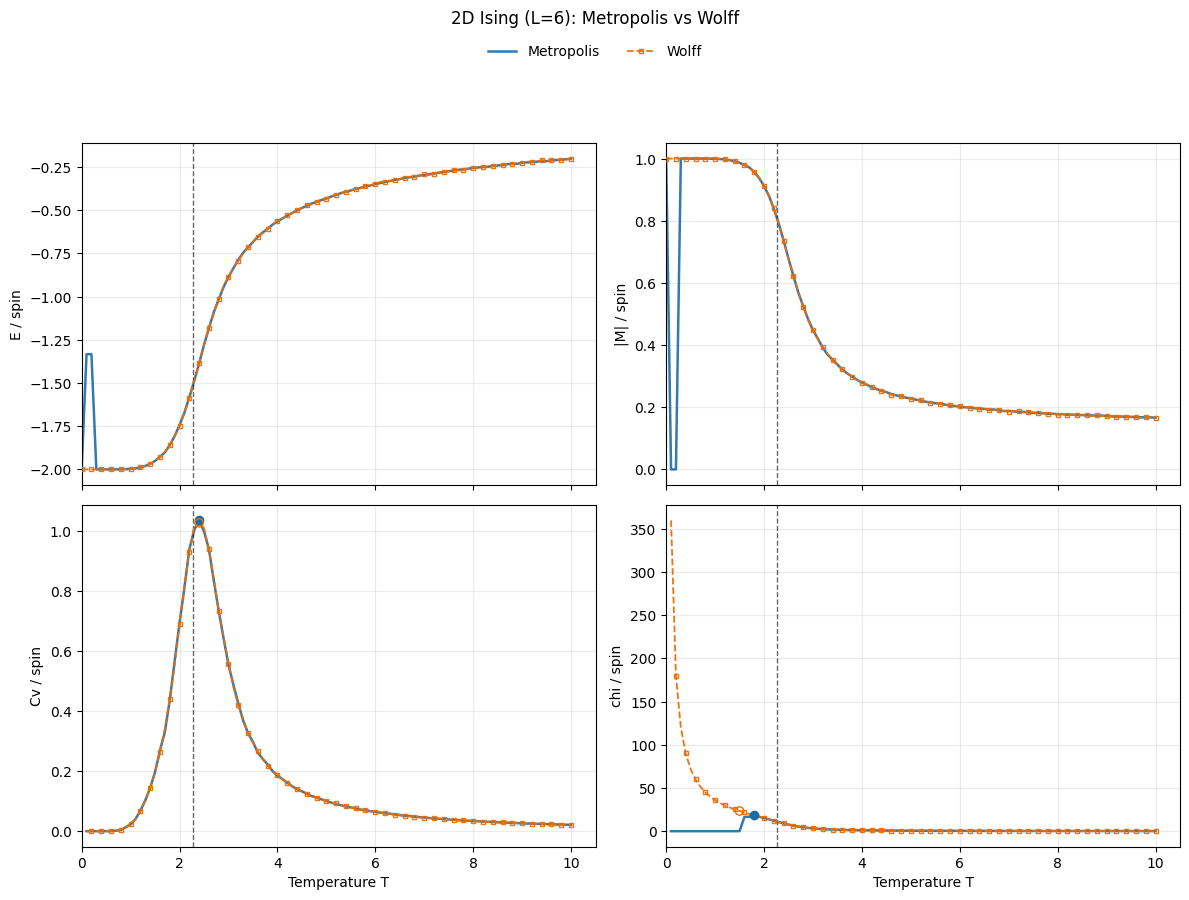

Figure saved: ising_summary_6x6_notebook.png
Reference critical temperature Tc = 2.269185
[Metropolis]
  Cv peak (window 1.5-3.5): T=2.400, Cv=1.03643
  chi peak (window 1.5-3.5): T=1.800, chi=18.3647
  Low-T: E/N=-2, |M|/N=1
  High-T: E/N=-0.202279, |M|/N=0.166178
[Wolff]
  Cv peak (window 1.5-3.5): T=2.400, Cv=1.02806
  chi peak (window 1.5-3.5): T=1.500, chi=23.3794
  Low-T: E/N=-2, |M|/N=1
  High-T: E/N=-0.201318, |M|/N=0.166532


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters.
metro_path = "ising_metro_6x6.csv"
wolff_path = "ising_wolff_6x6.csv"
out_fig = "ising_summary_6x6_notebook.png"
critical_window = (1.5, 3.5)
Tc = 2.0 / np.log(1.0 + np.sqrt(2.0))

# Load data.
metro = pd.read_csv(metro_path).sort_values("T").reset_index(drop=True)
wolff = pd.read_csv(wolff_path).sort_values("T").reset_index(drop=True)

required_cols = ["T", "E_per_spin", "M_abs_per_spin", "Cv_per_spin", "chi_per_spin"]
for name, df in [("Metropolis", metro), ("Wolff", wolff)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")


def finite_argmax(series, mask=None):
    vals = series.to_numpy(dtype=float)
    finite = np.isfinite(vals)
    if mask is not None:
        finite = finite & np.asarray(mask, dtype=bool)
    if not finite.any():
        raise ValueError("No finite data available for peak search.")
    indices = np.where(finite)[0]
    return int(indices[np.argmax(vals[finite])])


# Peak search in a critical window.
def get_peaks(df):
    positive_t = df["T"] > 0
    in_window = (df["T"] >= critical_window[0]) & (df["T"] <= critical_window[1])
    valid = positive_t & in_window
    i_cv = finite_argmax(df["Cv_per_spin"], valid)
    i_chi = finite_argmax(df["chi_per_spin"], valid)
    return i_cv, i_chi


im_cv, im_chi = get_peaks(metro)
iw_cv, iw_chi = get_peaks(wolff)

# Plot overview.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
ax_e, ax_m, ax_cv, ax_chi = axes.flat

style_m = dict(
    color="#1b6ca8",
    linewidth=1.8,
    alpha=0.9,
    zorder=2,
    label="Metropolis",
)
style_w = dict(
    color="#ef6c00",
    marker="s",
    markersize=3.2,
    linewidth=1.3,
    linestyle="--",
    alpha=0.95,
    markerfacecolor="none",
    markeredgecolor="#ef6c00",
    markeredgewidth=1.0,
    markevery=2,
    zorder=3,
    label="Wolff",
)

ax_e.plot(metro["T"], metro["E_per_spin"], **style_m)
ax_e.plot(wolff["T"], wolff["E_per_spin"], **style_w)
ax_e.set_ylabel("E / spin")
ax_e.grid(alpha=0.25)

ax_m.plot(metro["T"], metro["M_abs_per_spin"], **style_m)
ax_m.plot(wolff["T"], wolff["M_abs_per_spin"], **style_w)
ax_m.set_ylabel("|M| / spin")
ax_m.grid(alpha=0.25)

ax_cv.plot(metro["T"], metro["Cv_per_spin"], **style_m)
ax_cv.plot(wolff["T"], wolff["Cv_per_spin"], **style_w)
ax_cv.scatter(metro.loc[im_cv, "T"], metro.loc[im_cv, "Cv_per_spin"], color=style_m["color"], zorder=5)
ax_cv.scatter(wolff.loc[iw_cv, "T"], wolff.loc[iw_cv, "Cv_per_spin"], facecolors="none", edgecolors=style_w["color"], zorder=6)
ax_cv.set_ylabel("Cv / spin")
ax_cv.set_xlabel("Temperature T")
ax_cv.grid(alpha=0.25)

ax_chi.plot(metro["T"], metro["chi_per_spin"], **style_m)
ax_chi.plot(wolff["T"], wolff["chi_per_spin"], **style_w)
ax_chi.scatter(metro.loc[im_chi, "T"], metro.loc[im_chi, "chi_per_spin"], color=style_m["color"], zorder=5)
ax_chi.scatter(wolff.loc[iw_chi, "T"], wolff.loc[iw_chi, "chi_per_spin"], facecolors="none", edgecolors=style_w["color"], zorder=6)
ax_chi.set_ylabel("chi / spin")
ax_chi.set_xlabel("Temperature T")
ax_chi.grid(alpha=0.25)

for ax in axes.flat:
    ax.axvline(Tc, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_xlim(left=0)

handles, labels = ax_e.get_legend_handles_labels()
fig.suptitle("2D Ising (L=6): Metropolis vs Wolff", y=0.995)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig(out_fig, dpi=220)
plt.show()

print(f"Figure saved: {out_fig}")

# Text summary.
def summary_text(df, name, i_cv, i_chi):
    e0 = df.loc[df["T"].idxmin(), "E_per_spin"]
    m0 = df.loc[df["T"].idxmin(), "M_abs_per_spin"]
    eh = df.loc[df["T"].idxmax(), "E_per_spin"]
    mh = df.loc[df["T"].idxmax(), "M_abs_per_spin"]
    return (
        f"[{name}]\n"
        f"  Cv peak (window {critical_window[0]:.1f}-{critical_window[1]:.1f}): "
        f"T={df.loc[i_cv, 'T']:.3f}, Cv={df.loc[i_cv, 'Cv_per_spin']:.6g}\n"
        f"  chi peak (window {critical_window[0]:.1f}-{critical_window[1]:.1f}): "
        f"T={df.loc[i_chi, 'T']:.3f}, chi={df.loc[i_chi, 'chi_per_spin']:.6g}\n"
        f"  Low-T: E/N={e0:.6g}, |M|/N={m0:.6g}\n"
        f"  High-T: E/N={eh:.6g}, |M|/N={mh:.6g}"
    )

print(f"Reference critical temperature Tc = {Tc:.6f}")
print(summary_text(metro, "Metropolis", im_cv, im_chi))
print(summary_text(wolff, "Wolff", iw_cv, iw_chi))

## 结论要点（可按运行结果微调）

1. 两种算法在 $E/N$ 与 $|M|/N$ 的整体趋势上基本一致：低温有序、高温无序。
2. $C_v$ 在临界附近出现峰值（有限尺寸下峰位与热力学极限存在偏移）。
3. Wolff 团簇更新在临界区域通常能更快 decorrelate（实际误差与统计效率可结合独立重复或自相关时间进一步比较）。
4. 对于小系统 $L=6$，峰值位置与理论 $T_c$ 的偏差是有限尺寸效应的正常表现。

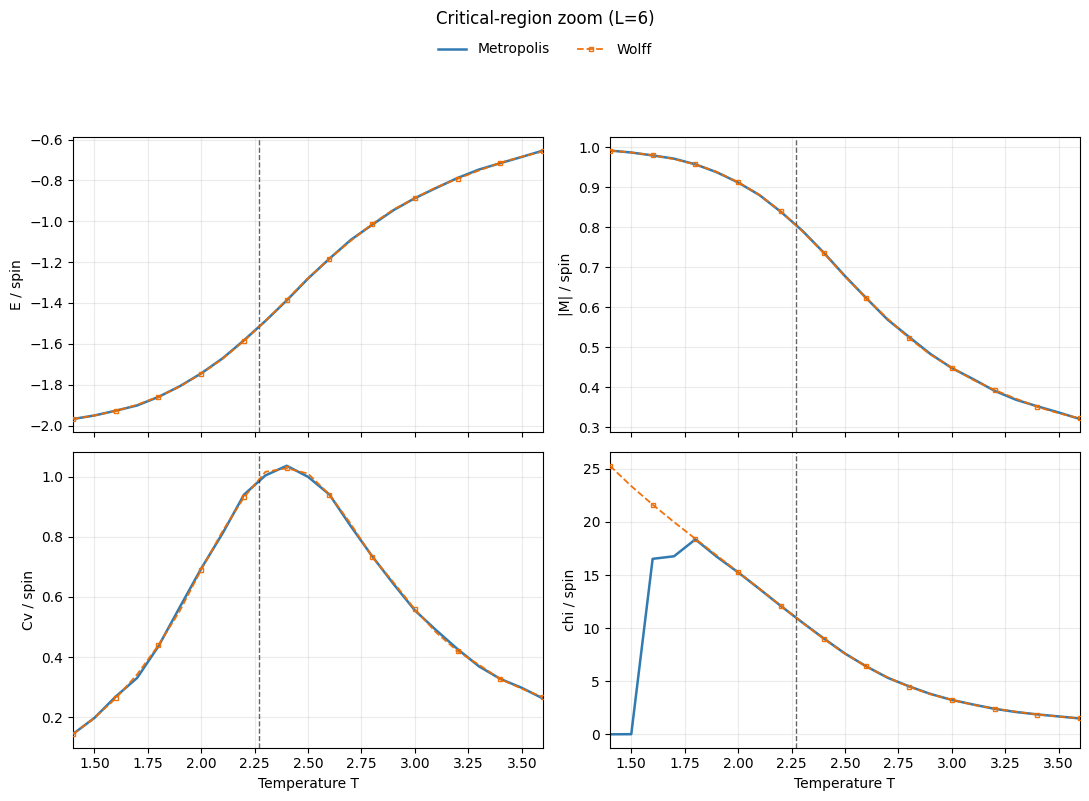

E_per_spin: mean(|Δ|) = 0.0150135, max(|Δ|) = 0.66667
M_abs_per_spin: mean(|Δ|) = 0.0205649, max(|Δ|) = 1
Cv_per_spin: mean(|Δ|) = 0.00184459, max(|Δ|) = 0.012358
chi_per_spin: mean(|Δ|) = 12.0186, max(|Δ|) = 360
Critical zoom figure saved: ising_critical_zoom_6x6.png


In [14]:
# Critical-region zoom and quantitative comparison.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metro = pd.read_csv("ising_metro_6x6.csv").sort_values("T").reset_index(drop=True)
wolff = pd.read_csv("ising_wolff_6x6.csv").sort_values("T").reset_index(drop=True)

Tc = 2.0 / np.log(1.0 + np.sqrt(2.0))
window = (1.4, 3.6)
mask_m = (metro["T"] >= window[0]) & (metro["T"] <= window[1])
mask_w = (wolff["T"] >= window[0]) & (wolff["T"] <= window[1])

m = metro.loc[mask_m].copy()
w = wolff.loc[mask_w].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
ax_e, ax_mg, ax_cv, ax_chi = axes.flat

style_m = dict(
    color="#1b6ca8",
    linewidth=1.8,
    alpha=0.9,
    zorder=2,
    label="Metropolis",
)
style_w = dict(
    color="#ef6c00",
    marker="s",
    markersize=3.2,
    linewidth=1.3,
    linestyle="--",
    alpha=0.95,
    markerfacecolor="none",
    markeredgecolor="#ef6c00",
    markeredgewidth=1.0,
    markevery=2,
    zorder=3,
    label="Wolff",
)

ax_e.plot(m["T"], m["E_per_spin"], **style_m)
ax_e.plot(w["T"], w["E_per_spin"], **style_w)
ax_e.set_ylabel("E / spin")
ax_e.grid(alpha=0.25)

ax_mg.plot(m["T"], m["M_abs_per_spin"], **style_m)
ax_mg.plot(w["T"], w["M_abs_per_spin"], **style_w)
ax_mg.set_ylabel("|M| / spin")
ax_mg.grid(alpha=0.25)

ax_cv.plot(m["T"], m["Cv_per_spin"], **style_m)
ax_cv.plot(w["T"], w["Cv_per_spin"], **style_w)
ax_cv.set_ylabel("Cv / spin")
ax_cv.set_xlabel("Temperature T")
ax_cv.grid(alpha=0.25)

ax_chi.plot(m["T"], m["chi_per_spin"], **style_m)
ax_chi.plot(w["T"], w["chi_per_spin"], **style_w)
ax_chi.set_ylabel("chi / spin")
ax_chi.set_xlabel("Temperature T")
ax_chi.grid(alpha=0.25)

for ax in axes.flat:
    ax.axvline(Tc, ls="--", lw=1.0, color="k", alpha=0.6)
    ax.set_xlim(*window)

handles, labels = ax_e.get_legend_handles_labels()
fig.suptitle("Critical-region zoom (L=6)", y=0.995)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=[0, 0, 1, 0.9])
fig.savefig("ising_critical_zoom_6x6.png", dpi=220)
plt.show()

# Compare the two methods on common temperature points.
merged = metro.merge(wolff, on="T", suffixes=("_m", "_w"))
for col in ["E_per_spin", "M_abs_per_spin", "Cv_per_spin", "chi_per_spin"]:
    diff = np.abs(merged[f"{col}_m"] - merged[f"{col}_w"])
    print(f"{col}: mean(|Δ|) = {diff.mean():.6g}, max(|Δ|) = {diff.max():.6g}")

print("Critical zoom figure saved: ising_critical_zoom_6x6.png")